# Week 1: Image Basics & OpenCV

**Computer Vision Fundamentals** — Temasek Poly IIT AAI

*(Teacher copy — full solutions and explanations. Use the student copy for in-class fill-in.)*

This notebook introduces what an image is in the computer, how it is stored in memory, and how we work with images using OpenCV and NumPy.

---
## 1.1 Introduction to Computer Vision

**Computer Vision (CV)** is the field of teaching machines to "see"—to understand and interpret images and video.

### History and applications
- **Security**: Face recognition, surveillance, access control
- **Manufacturing**: Quality inspection, defect detection, robotics
- **Agriculture**: Crop health, yield estimation, autonomous harvesters
- **Healthcare**: Medical imaging (X-rays, MRI), diagnosis support
- **Transport**: Self-driving cars, traffic monitoring, license plate recognition
- **Entertainment**: Augmented reality, photo filters, gaming

### Traditional AI vs ML/DL
- **Traditional / classical CV**: Rule-based methods (edges, corners, thresholds). Fast, interpretable, works well when the problem is well-defined (e.g. barcode reading).
- **Machine Learning / Deep Learning**: Learn patterns from data. Better for complex, varied scenes (e.g. recognising any object).
- **In practice**: We often combine both—classical CV for preprocessing (e.g. finding regions), and ML/DL for recognition.

---
## 1.2 Image Data Representation

An image on disk (e.g. JPEG, PNG) is stored in a compressed format. When we **load** it into memory with OpenCV, it becomes a **NumPy array** of numbers.

### Key ideas
- **Channels**: Colour images usually have 3 channels—Red, Green, Blue (RGB). Each pixel has 3 numbers.
- **Bit depth**: How many bits per channel. **8-bit** per channel is very common → values from **0 to 255** (2⁸ = 256 levels).
- **Grayscale**: One channel only. 0 = black, 255 = white.
- **RGB vs RGBA**: RGBA adds an **alpha** channel for transparency (e.g. PNG with transparency).
- **OpenCV convention**: When you read an image with `cv2.imread()`, the order of channels is **BGR** (Blue, Green, Red), not RGB. This matters when displaying with Matplotlib (which expects RGB) or when you index channels.

### Connecting bits/bytes to the screen
- 8 bits = 1 byte per channel. So one RGB pixel = 3 bytes = 24 bits ("24-bit colour").
- The numbers 0–255 are what the display hardware uses to set the intensity of each colour; 0 means "off", 255 means "full".

---
## 1.3 Setup: Imports and Loading an Image

We use **OpenCV** (`cv2`) to load and process images, **NumPy** for array operations, and **Matplotlib** to display them.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Load a sample image from the `data` folder. We use a path relative to the notebook so it works from the `week-1` directory.

In [11]:
image_path = 'data/marina_bay_sands.jpg'
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f'Image not found: {image_path}. Run this notebook from the week-1 folder.')

print('Image loaded successfully!')

Image loaded successfully!


### Displaying the image with Matplotlib

Matplotlib expects **RGB** order. OpenCV gives us **BGR**. So we convert before displaying, otherwise colours look wrong (e.g. red and blue swapped).

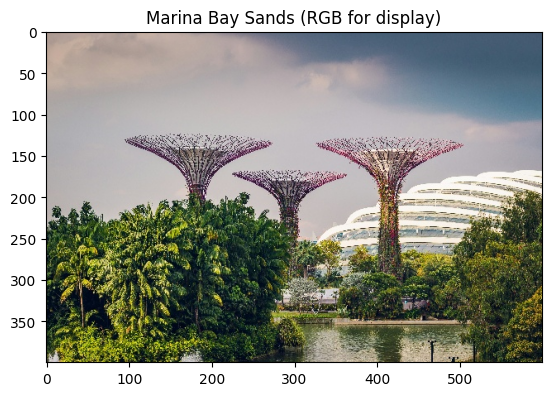

In [12]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Marina Bay Sands (RGB for display)')
plt.show()

---
## 1.4 Inspecting the NumPy Array

The image is just a NumPy array. We inspect its **shape**, **dtype**, and **value range**.

In [ ]:
print('Shape:', img.shape)   # (height, width, channels)
print('Dtype:', img.dtype)   # usually uint8 for 8-bit images
print('Min value:', img.min(), '| Max value:', img.max())

Shape: (400, 600, 3)
Dtype: uint8
Min value: 0 | Max value: 255


**Interpretation:**
- `shape` is `(H, W, C)`: height (rows), width (columns), number of channels (3 for BGR).
- `dtype` is `uint8`: unsigned 8-bit integer → values 0–255.
- Min/max confirm the pixel values lie in that range.

### Basic NumPy operations: indexing and slicing

- **Single pixel** (e.g. at row 100, column 200): `img[100, 200]` → array `[B, G, R]`.
- **Region of interest (ROI)**: `img[y1:y2, x1:x2]` gives a rectangular patch.
- **Single channel**: `img[:, :, 0]` is the Blue channel; `img[:, :, 1]` Green; `img[:, :, 2]` Red.

In [13]:
h, w, c = img.shape
center_y, center_x = h // 2, w // 2
pixel_bgr = img[center_y, center_x]
print(f'Center pixel (B,G,R): {pixel_bgr}')

roi = img[50:150, 100:200]  # region: rows 50–149, columns 100–199
print(f'ROI shape: {roi.shape}')

Center pixel (B,G,R): [43 15 38]
ROI shape: (100, 100, 3)


---
## 1.5 Grayscale and Channel Splitting

**Grayscale** = single channel. OpenCV can convert BGR → grayscale. We can also extract one channel or combine channels.

In [14]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print('Grayscale shape:', gray.shape)  # (H, W) — no channel dimension
print('Grayscale dtype:', gray.dtype, '| Min:', gray.min(), 'Max:', gray.max())

Grayscale shape: (3326, 4989)
Grayscale dtype: uint8 | Min: 0 Max: 255


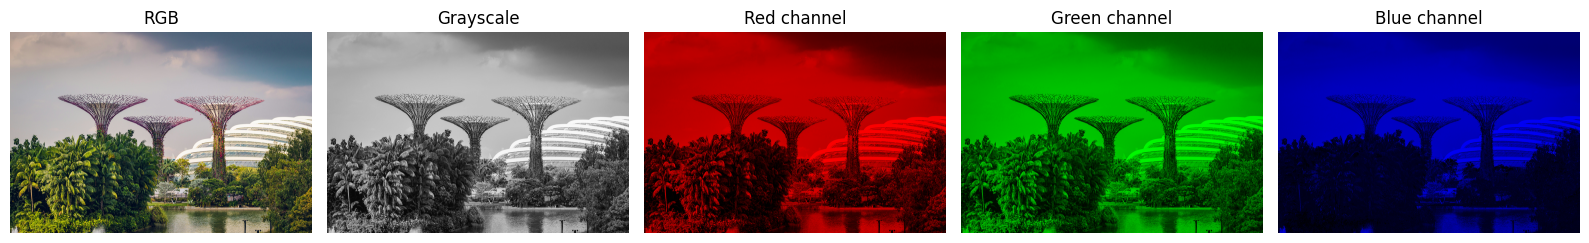

In [15]:
b, g, r = cv2.split(img)
# Build RGB images with only one channel non-zero (so they appear red, green, or blue)
red_only_rgb = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=-1)
green_only_rgb = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=-1)
blue_only_rgb = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=-1)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('RGB')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(red_only_rgb)
axes[2].set_title('Red channel')
axes[2].axis('off')

axes[3].imshow(green_only_rgb)
axes[3].set_title('Green channel')
axes[3].axis('off')

axes[4].imshow(blue_only_rgb)
axes[4].set_title('Blue channel')
axes[4].axis('off')

plt.tight_layout()
plt.show()

---
## 1.6 Storage and Transport Formats

Images can be stored or sent in different ways:
- **File formats**: JPEG (lossy), PNG (lossless, can have alpha), BMP (uncompressed), etc.
- **In databases / APIs**: Sometimes images are stored as **byte strings** (e.g. base64-encoded) rather than raw arrays. That is useful in systems that are not "vector-friendly" (e.g. certain SQL databases or JSON payloads). OpenCV can decode from memory: `cv2.imdecode(np.frombuffer(bytes_data, dtype=np.uint8), cv2.IMREAD_COLOR)`.

---
## 1.7 Application: Colour-based masking with HSV

**Why use another colour scale?** In **RGB**, a single "colour" (e.g. red) is a mix of R, G, B, so selecting "all red pixels" is awkward. In **HSV** (Hue, Saturation, Value), **Hue** is the colour angle (e.g. red, blue), **Saturation** is how vivid it is, **Value** is brightness. That makes it easier to isolate regions by colour.

**Simple application:** Isolate bluish tones (e.g. sky or water) using a range in Hue. We convert to HSV, define lower/upper bounds, and use `cv2.inRange()` to get a mask, then show the masked result.

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# In OpenCV: H is 0--179, S and V are 0--255. Blue hues are around 100--130.
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# Show original, mask, and masked image (colour only where mask is 255)
masked_rgb = img_rgb.copy()
masked_rgb[mask_blue == 0] = 0  # black out where mask is 0

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(mask_blue, cmap='gray')
axes[1].set_title('Mask (blue regions)')
axes[1].axis('off')
axes[2].imshow(masked_rgb)
axes[2].set_title('Colour only in blue regions')
axes[2].axis('off')
plt.tight_layout()
plt.show()

---
## 1.8 In class: Different ways to darken and brighten

We change brightness by changing pixel values. All methods must keep values in **0–255** (e.g. with `np.clip`) and convert back to `uint8`.

**Method 1 — Add/subtract a constant:**
- Brighter: add a positive number (e.g. +40).
- Darker: subtract a positive number (e.g. -40).

**Method 2 — Multiply by a factor:**
- Brighter: multiply by > 1 (e.g. 1.3).
- Darker: multiply by < 1 (e.g. 0.6).

**Method 3 — Scale then offset:** Combine: e.g. `(img * factor) + offset`, then clip. Gives more control (e.g. brighten midtones without blowing out highlights).

In [ ]:
# Work in float to avoid overflow, then clip and convert back to uint8
img_f = img.astype(np.float32)

# Method 1: Add/subtract constant
brighter_add = np.clip(img_f + 50, 0, 255).astype(np.uint8)
darker_add = np.clip(img_f - 50, 0, 255).astype(np.uint8)

# Method 2: Multiply by factor
brighter_mul = np.clip(img_f * 1.35, 0, 255).astype(np.uint8)
darker_mul = np.clip(img_f * 0.6, 0, 255).astype(np.uint8)

# Method 3: Scale + offset (e.g. gentle brighten)
brighter_scale = np.clip(img_f * 1.1 + 20, 0, 255).astype(np.uint8)

# Display: convert BGR to RGB for matplotlib
def bgr_to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(bgr_to_rgb(img))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
axes[0, 1].imshow(bgr_to_rgb(brighter_add))
axes[0, 1].set_title('Brighter (+50)')
axes[0, 1].axis('off')
axes[0, 2].imshow(bgr_to_rgb(darker_add))
axes[0, 2].set_title('Darker (-50)')
axes[0, 2].axis('off')
axes[1, 0].imshow(bgr_to_rgb(brighter_mul))
axes[1, 0].set_title('Brighter (×1.35)')
axes[1, 0].axis('off')
axes[1, 1].imshow(bgr_to_rgb(darker_mul))
axes[1, 1].set_title('Darker (×0.6)')
axes[1, 1].axis('off')
axes[1, 2].imshow(bgr_to_rgb(brighter_scale))
axes[1, 2].set_title('Brighter (×1.1 + 20)')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

---
## 1.9 Summary

- An image in memory is a **NumPy array** (e.g. shape `(H, W, 3)` for BGR, dtype `uint8`).
- **Channels**: BGR in OpenCV; convert to RGB for Matplotlib. Grayscale = one channel.
- **8-bit** per channel → values **0–255**. Use **shape**, **dtype**, and **slicing** to inspect and manipulate pixels.
- **HSV** is useful for colour-based masking (e.g. `cv2.inRange` on Hue).
- **Brightness** can be changed by add/subtract, multiply, or scale+offset; always clip to 0–255 and use `astype(np.uint8)`.
- Classical CV + ML/DL are complementary; we often use both in real applications.